In [1]:
import math
import cmath

import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy import integrate
from scipy.linalg import null_space
from scipy.optimize import fsolve
from scipy.integrate import solve_bvp

In [2]:
from joblib import Parallel, delayed
import multiprocessing

# sets the number of parallel processes equal to the number of CPU cores on your machine
n_jobs = multiprocessing.cpu_count()

In [3]:
%matplotlib notebook

In [238]:
# length
L = 1.7

# orbital number
l = 2

# coupling srength left/right
t_L = 1
t_R = t_L

# effective mass, SC gap
mx = 9 # 9

Delta = 1

# continuum temperature

T_ferm = 0.3

# fermionic Matsubara frequencies 
ferm_freq = 1j * np.pi * T_ferm * np.arange(-1001, 1003, 2)

# SOI, ZF

b_x = 0.001 # 0.46
b_z = 0.0

gamma_SO = 0.0001

# Coulomb, backgare voltage
Ec = 0.95
Vg_min_mu = -1

tau_z = np.block([[np.eye(4), np.zeros((4, 4))], [np.zeros((4, 4)), -np.eye(4)]])

In [145]:
phi_0 = np.linspace(0, np.pi, num=41)

# phi_0[0] = 0.001
# phi_0[-1] -= 0.001
# phi_0[50] += 0.001

In [6]:
# initializing MFA 

MF_param = np.zeros((len(phi_0), 2*l))
accur_par = 10**(-3)
abs_diff = np.full((len(phi_0), 2*l), np.inf)

In [7]:
def fermi_distrib(x, T):
    return 1/(np.exp(x/T)+1)

### Finding free dot eigenenergies and eigenfunctions -  hopping parameters

In [10]:
def chi_n_sigma(x, n, sigma):
    
    q = mx*gamma_SO
    k_n = n*np.pi/L
    
    cos_n = (k_n + sigma*q)/np.sqrt(2*(k_n**2 + q**2))
    sin_n = (k_n - sigma*q)/np.sqrt(2*(k_n**2 + q**2))
    
    f = np.exp(-1j*sigma*q*(x - L/2)) * (cos_n * np.exp(1j*k_n*(x-L/2)) + \
                                   sin_n * np.exp(-1j*k_n*(x-L/2)))
    
    return f/np.sqrt(L)

<IPython.core.display.Javascript object>


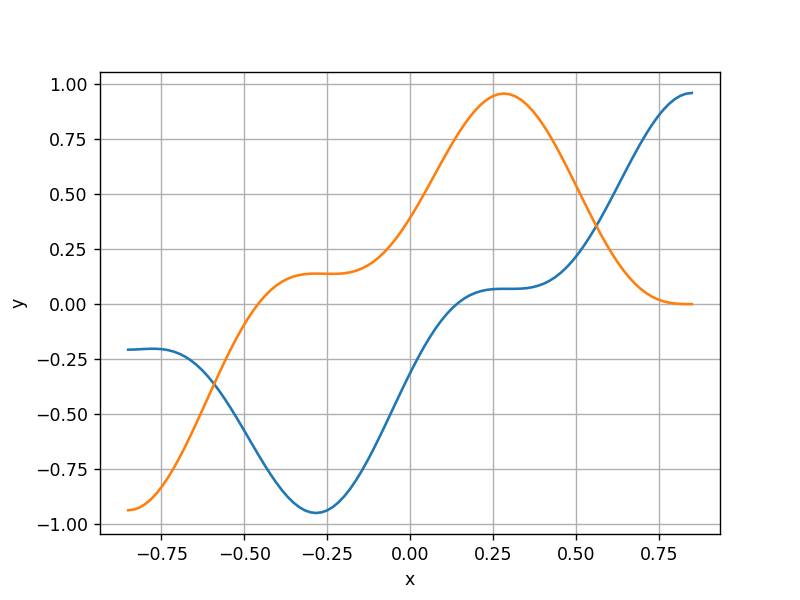

In [11]:
x_plot = np.linspace(-L/2, L/2, 100)

plt.xlabel("x")
plt.ylabel("y")



plt.plot(x_plot, np.real(chi_n_sigma(x_plot, 3, -1)))
plt.plot(x_plot, np.imag(chi_n_sigma(x_plot, 3, -1)))

plt.grid()

In [9]:
def cos_n_s(n, sigma):
    k_n = n*np.pi/L
    q = mx*gamma_SO
    
    cos_n = (k_n + sigma*q)/np.sqrt(2*(k_n**2 + q**2))
    
    return cos_n   

In [10]:
def J_mn_sigma(m, n, sigma):
    
    q = mx*gamma_SO
    k_n = n*np.pi/L
    k_m = m*np.pi/L
    
    f_s_mn = cos_n_s(n, sigma) * cos_n_s(m, -sigma) / (k_n - k_m - 2*q*sigma) -\
             cos_n_s(n, -sigma) * cos_n_s(m, sigma) / (k_n - k_m + 2*q*sigma) +\
             cos_n_s(n, sigma) * cos_n_s(m, sigma) / (k_n + k_m - 2*q*sigma) -\
             cos_n_s(n, -sigma) * cos_n_s(m, -sigma) / (k_n + k_m + 2*q*sigma)
    
    if (-1)**(n+m) == 1:
        J = 2*b_x * f_s_mn / L * (-sigma)*np.sin(q*L)
    if (-1)**(n+m) == -1:
        J = 2*b_x * f_s_mn / L * (-1j)*np.cos(q*L)
    
    return J

In [146]:
N = 20
n_arr = np.arange(1, N + 1)
q = mx*gamma_SO

k_n = n_arr * np.pi / L
eps_n = k_n**2 / (2 * mx) - mx*gamma_SO**2/2 + Vg_min_mu
m_one_arr = (-1)**n_arr

xi_n = np.sqrt(2/L) * k_n / np.sqrt(k_n**2 + (mx*gamma_SO)**2)

J_min = np.zeros((N, N), dtype='complex')
J_pl = np.zeros_like(J_min)

for n in range(N):
    for m in range(N):
        J_min[n, m] = J_mn_sigma(n+1, m+1, -1)
        J_pl[m, n] = np.conjugate(J_min[n, m])       

In [147]:
H_2 = np.zeros((2*N, 2*N), dtype='complex')

diagonal_elements = np.array([(eps + b_z, eps - b_z) for eps in eps_n]).flatten()
H_diag = np.diag(diagonal_elements)

for n in range(N):
    for m in range(N):
        H_2[2*n, 2*m+1] = J_min[n, m]
        H_2[2*n+1, 2*m] = J_pl[n, m]
        
H_2 += H_diag
E_2, Psi_2 = LA.eigh(H_2)

for i in range(2*N):
    sum_i = np.real(np.sum(Psi_2[:, i]**2))
    Psi_2[:, i] /= sum_i
    
even_rows = Psi_2[::2, :]
u = np.sum(xi_n[:, np.newaxis] * even_rows, axis=0)
t_L_up = np.exp(1j*L*q) * np.sum(m_one_arr[:, np.newaxis] * xi_n[:, np.newaxis] * even_rows, axis=0)


odd_rows = Psi_2[1::2, :]
v = np.sum(xi_n[:, np.newaxis] * odd_rows, axis=0)
t_L_down = np.exp(-1j*L*q) * np.sum(m_one_arr[:, np.newaxis] * xi_n[:, np.newaxis] * odd_rows, axis=0)

In [148]:
E_2[0:2*l]

array([-0.81127293, -0.80927293, -0.24209159, -0.2400916 ])

In [149]:
Gamma_L = np.zeros((4, 4), dtype='complex')
Gamma_R = np.zeros_like(Gamma_L)
F_R = np.zeros_like(Gamma_L)
F_L = np.zeros_like(Gamma_L)

for mu in range(4):
    for nu in range(4):
        Gamma_R[mu, nu] = np.conjugate(u[mu])*u[nu] + np.conjugate(v[mu])*v[nu]
        Gamma_L[mu, nu] = u[mu]*np.conjugate(u[nu]) + v[mu]*np.conjugate(v[nu])
    
        F_R[mu, nu] = u[mu]*v[nu] - u[nu]*v[mu]
        F_L[mu, nu] = np.conjugate(u[mu]*v[nu] - u[nu]*v[mu])  

Gamma_L *= t_L**2
Gamma_R *= t_L**2
F_L *= t_L**2
F_R *= t_L**2

### MF Hamiltonian

In [15]:
def det_G_inv(x, i, MF_param):
    
    s_L = 1
    s_R = -1
    zero_m = np.zeros_like(Gamma_L)
    
    
    Lambda = -1 / cmath.sqrt(Delta**2 - x**2) \
            * (x * np.block([[(Gamma_L + Gamma_R), zero_m], [zero_m, np.conjugate(Gamma_L + Gamma_R)]]) \
            + Delta * np.block([[zero_m, np.exp(-1j * s_L * phi_0[i]/2) * np.conjugate(np.transpose(F_L))], \
                                [np.exp(1j * s_L * phi_0[i]/2) * F_L, zero_m]]) \
            + Delta * np.block([[zero_m, np.exp(-1j * s_R * phi_0[i]/2) * np.conjugate(np.transpose(F_R))], \
                                [np.exp(1j * s_R * phi_0[i]/2) * F_R, zero_m]]))
    
    G_inv = x * np.eye(4*l) - np.block([[np.diag(E_2[0:2*l]) - 2*1j*Ec*np.diag(MF_param[i]), zero_m],\
                                        [zero_m, -np.diag(E_2[0:2*l]) + 2*1j*Ec*np.diag(MF_param[i])]]) - Lambda
    
    return LA.det(G_inv)   

Here algorithmically one does not need to compute the ABS energies. But one can compute them illustratively 

In [16]:
roots = np.zeros((len(phi_0), 4*l))

for i in range(len(phi_0)):
    roots[i, 0] = fsolve(det_G_inv, 0.3, args=(i, MF_param))  
    roots[i, 1] = fsolve(det_G_inv, 0.8, args=(i, MF_param))  
    roots[i, 2] = fsolve(det_G_inv, 0.9908, args=(i, MF_param)) 
    roots[i, 3] = fsolve(det_G_inv, 0.9999, args=(i, MF_param))
    
    roots[i, 4] = fsolve(det_G_inv, -0.7, args=(i, MF_param))  
    roots[i, 5] = fsolve(det_G_inv, -0.8, args=(i, MF_param))     
    roots[i, 6] = fsolve(det_G_inv, -0.9, args=(i, MF_param))  
    roots[i, 7] = fsolve(det_G_inv, -0.9999, args=(i, MF_param))   
    
# for i in range(20):
#     roots[i, 1] = fsolve(G_inv, 0.63, args=(i)) 
#     roots[-i, 1] = fsolve(G_inv, 0.57, args=(-i)) 
    
#     roots[i, 5] = fsolve(G_inv, -0.63, args=(i)) # 0.6
#     roots[-i, 5] = fsolve(G_inv, -0.57, args=(-i))     

/home/katya-zats/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:240: ComplexWarning: Casting complex values to real discards the imaginary part
  retval = _minpack._hybrd(func, x0, args, 1, xtol, maxfev,


<IPython.core.display.Javascript object>


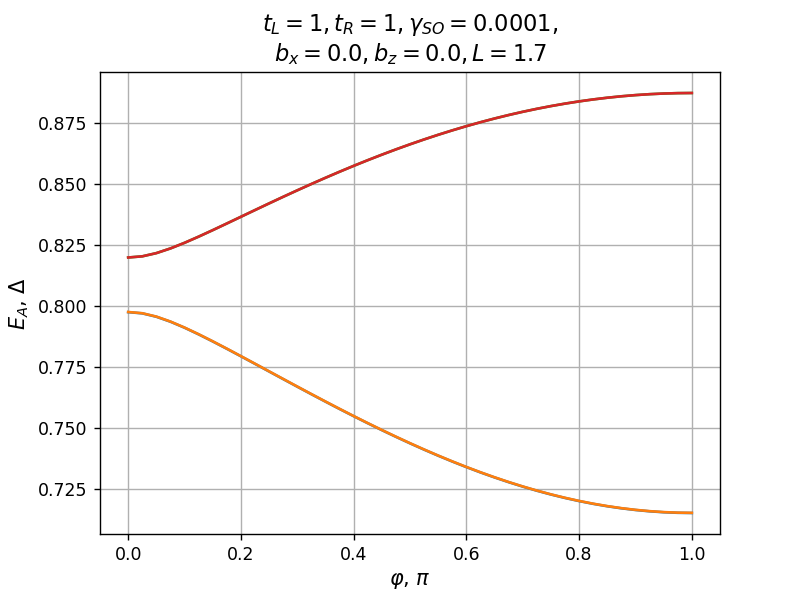

Text(0, 0.5, '$E_A$, $\\Delta$')

In [17]:
plt.plot(phi_0/np.pi, roots[:,0], linewidth=1.5)
plt.plot(phi_0/np.pi, roots[:,1], linewidth=1.5)
plt.plot(phi_0/np.pi, roots[:,2], linewidth=1.5)
plt.plot(phi_0/np.pi, roots[:,3], linewidth=1.5)


plt.title(r"$t_L={}, t_R={}, \gamma_{{SO}} = {},$"\
          .format(t_L, t_R, gamma_SO)+'\n'+
          r"$b_x={}, b_z = {}, L={}$"\
          .format(np.round(b_x, 2), np.round(b_z, 2), L), fontsize=13)



plt.grid()
plt.xlabel(r'$\varphi$, $\pi$', fontsize=12)
plt.ylabel(r'$E_A$, $\Delta$', fontsize=12)


In [248]:
def G_inv(x, i, MF_param):
    
    s_L = 1
    s_R = -1
    zero_m = np.zeros_like(Gamma_L)
    
    
    Lambda = -1 / cmath.sqrt(Delta**2 - x**2) \
            * (x * np.block([[(Gamma_L + Gamma_R), zero_m], [zero_m, np.conjugate(Gamma_L + Gamma_R)]]) \
            + Delta * np.block([[zero_m, np.exp(-1j * s_L * phi_0[i]/2) * np.conjugate(np.transpose(F_L))], \
                                [np.exp(1j * s_L * phi_0[i]/2) * F_L, zero_m]]) \
            + Delta * np.block([[zero_m, np.exp(-1j * s_R * phi_0[i]/2) * np.conjugate(np.transpose(F_R))], \
                                [np.exp(1j * s_R * phi_0[i]/2) * F_R, zero_m]]))
    
    G_inv = x * np.eye(4*l) - np.block([[np.diag(E_2[0:2*l]) - 2*1j*Ec*np.diag(MF_param[i]), zero_m],\
                                        [zero_m, -np.diag(E_2[0:2*l]) + 2*1j*Ec*np.diag(MF_param[i])]]) - Lambda
    
    return G_inv  

### Mean-field parameter calculation

In [19]:
P_mn = np.array([np.diag(np.array([1, -1, 0, 0, 1, -1, 0, 0])),\
                 np.diag(np.array([1, 0, -1, 0, 1, 0, -1, 0])),\
                 np.diag(np.array([1, 0, 0, -1, 1, 0, 0, -1])),\
                 np.diag(np.array([0, 1, -1, 0, 0, 1, -1, 0])),\
                 np.diag(np.array([0, 1, 0, -1, 0, 1, 0, -1])),\
                 np.diag(np.array([0, 0, 1, -1, 0, 0, 1, -1]))])

In [20]:
def MS_mf_param(i, MF_param):
    
    Mats_sum = np.zeros(6, dtype='complex')
    
    for j in range(len(ferm_freq)):
        GF_j = G_inv(ferm_freq[j], i, MF_param)
        inv_GF_j = LA.inv(GF_j)

        for mu in range(6):
            Mats_sum[mu] += np.trace(inv_GF_j @ P_mn[mu] @ tau_z)
    
    return Mats_sum

In [21]:
# a helper function that computes the mean-field value at index i

def compute_single_MF(i, MF_param):
    return MS_mf_param(i, MF_param)

In [407]:
MF_param_matr = np.array(
    Parallel(n_jobs=n_jobs)(
        delayed(compute_single_MF)(i, MF_param) for i in range(len(phi_0))
    )
)

MF_param_matr *= T_ferm/2

In [408]:
# MF_param_new = np.zeros((len(phi_0), 4), dtype='complex')

# MF_param_new[:, 0] = MF_param_matr[:, 0] + MF_param_matr[:, 1] + MF_param_matr[:, 2] 
# MF_param_new[:, 1] = MF_param_matr[:, 3] + MF_param_matr[:, 4] - MF_param_matr[:, 0] 
# MF_param_new[:, 2] = MF_param_matr[:, 5] - MF_param_matr[:, 3] - MF_param_matr[:, 1] 
# MF_param_new[:, 3] = -MF_param_matr[:, 2] - MF_param_matr[:, 4] - MF_param_matr[:, 5] 

# Transformation matrix: 4 outputs as linear combinations of 6 inputs
T = np.array([
    [ 1,  1,  1,  0,  0,  0],
    [-1,  0,  0,  1,  1,  0],
    [ 0, -1,  0, -1,  0,  1],
    [ 0,  0, -1,  0, -1, -1]])

MF_param_new = MF_param_matr @ T.T  # (n, 6) × (6, 4) → (n, 4)

<IPython.core.display.Javascript object>


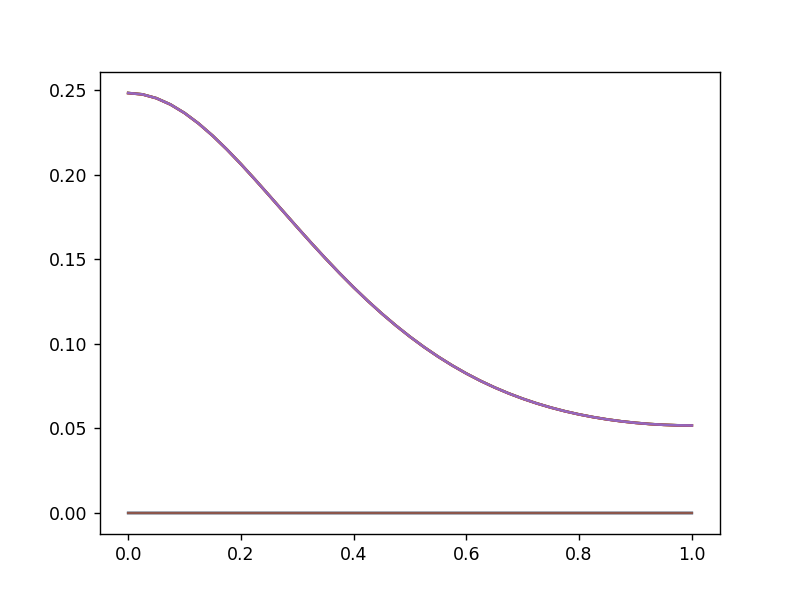

In [409]:
plt.plot(phi_0/np.pi, MF_param_matr)

<IPython.core.display.Javascript object>


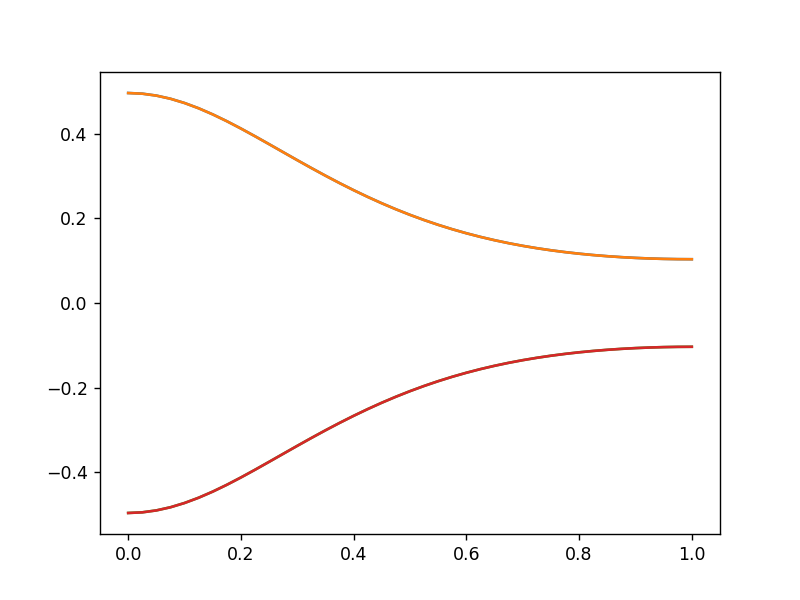

In [410]:
plt.plot(phi_0/np.pi, MF_param_new)

<IPython.core.display.Javascript object>


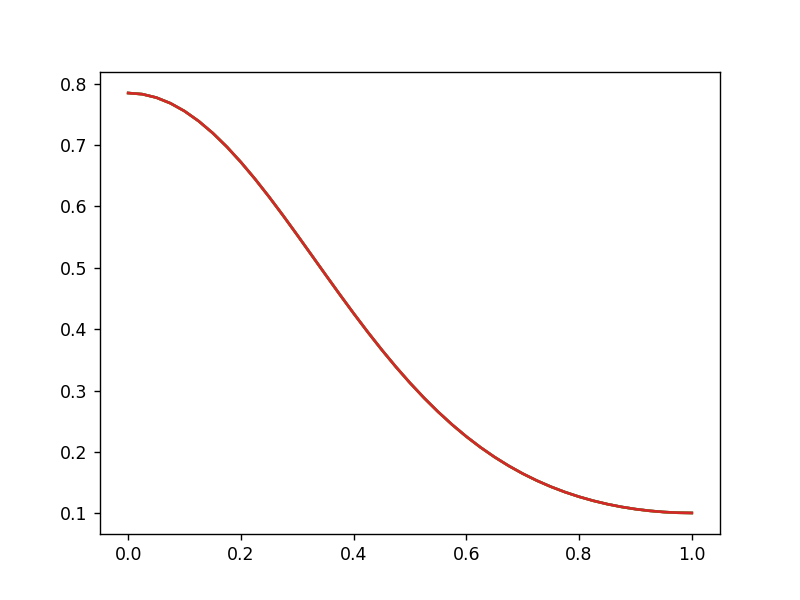

In [411]:
#  checking convergence

abs_diff = np.abs(MF_param_new - MF_param)

plt.plot(phi_0/np.pi, abs_diff)

In [412]:
MF_param = MF_param_new

### MFA loop

In [249]:
MF_param = np.zeros((len(phi_0), 2*l), dtype="complex")
accur_par = 1e-2
abs_diff = np.full((len(phi_0), 2*l), np.inf, dtype="float64")

MFA_count = 0
max_iter = 15

# # Track which phi_0 points are still not converged
# active_mask = np.full(len(phi_0), True)  # All True at start

while np.any(abs_diff > accur_par):
    
    if MFA_count >= max_iter:
        print("Reached max iterations.")
        break

    print(f"\n--- Iteration {MFA_count} ---")

#     # Compute only for non-converged points
#     active_indices = np.where(active_mask)[0]
    
    MF_param_matr = np.array(
        Parallel(n_jobs=n_jobs)(
            delayed(compute_single_MF)(i, MF_param) for i in range(len(phi_0))))

    MF_param_matr *= T_ferm / 2

    T = np.array([
        [ 1,  1,  1,  0,  0,  0],
        [-1,  0,  0,  1,  1,  0],
        [ 0, -1,  0, -1,  0,  1],
        [ 0,  0, -1,  0, -1, -1]])

    MF_param_new = MF_param_matr @ T.T  # shape (m, 4)

    # Compute absolute differences
    abs_diff = np.abs(MF_param_new - MF_param)

    # Update parameters 
    MF_param = MF_param_new

    print("Maximal abs difference:", np.round(np.max(abs_diff), 3))
    MFA_count += 1



--- Iteration 0 ---
Maximal abs difference: 0.149

--- Iteration 1 ---
Maximal abs difference: 0.149

--- Iteration 2 ---
Maximal abs difference: 0.148

--- Iteration 3 ---
Maximal abs difference: 0.147

--- Iteration 4 ---
Maximal abs difference: 0.146

--- Iteration 5 ---
Maximal abs difference: 0.146

--- Iteration 6 ---
Maximal abs difference: 0.145

--- Iteration 7 ---
Maximal abs difference: 0.144

--- Iteration 8 ---
Maximal abs difference: 0.143

--- Iteration 9 ---
Maximal abs difference: 0.143

--- Iteration 10 ---
Maximal abs difference: 0.142

--- Iteration 11 ---
Maximal abs difference: 0.141

--- Iteration 12 ---
Maximal abs difference: 0.141

--- Iteration 13 ---
Maximal abs difference: 0.14

--- Iteration 14 ---
Maximal abs difference: 0.139
Reached max iterations.


In [195]:
MF_param = np.zeros((len(phi_0), 2*l), dtype="complex")
accur_par = 1e-2
abs_diff = np.full((len(phi_0), 2*l), np.inf, dtype="float64")

MFA_count = 0
max_iter = 15

# Track which phi_0 points are still not converged
active_mask = np.full(len(phi_0), True)  # All True at start

while np.any(abs_diff[active_mask] > accur_par):
    
    if MFA_count >= max_iter:
        print("Reached max iterations.")
        break

    print(f"\n--- Iteration {MFA_count} ---")

    # Compute only for non-converged points
    active_indices = np.where(active_mask)[0]
    
    MF_param_matr_partial = np.array(
        Parallel(n_jobs=n_jobs)(
            delayed(compute_single_MF)(i, MF_param) for i in active_indices))

    MF_param_matr_partial *= T_ferm / 2

    T = np.array([
        [ 1,  1,  1,  0,  0,  0],
        [-1,  0,  0,  1,  1,  0],
        [ 0, -1,  0, -1,  0,  1],
        [ 0,  0, -1,  0, -1, -1]])

    MF_param_new_partial = MF_param_matr_partial @ T.T  # shape (m, 4)

    # Compute absolute differences
    abs_diff_partial = np.abs(MF_param_new_partial - MF_param[active_indices])
    abs_diff[active_indices] = abs_diff_partial

    # Update parameters only for active points
    MF_param[active_indices] = MF_param_new_partial

    # Update convergence mask
    active_mask = np.any(abs_diff > accur_par, axis=1)

    print("Remaining points to converge:", np.sum(active_mask))
    MFA_count += 1



--- Iteration 0 ---
Remaining points to converge: 41

--- Iteration 1 ---
Remaining points to converge: 41

--- Iteration 2 ---
Remaining points to converge: 41

--- Iteration 3 ---
Remaining points to converge: 41

--- Iteration 4 ---
Remaining points to converge: 41

--- Iteration 5 ---
Remaining points to converge: 41

--- Iteration 6 ---
Remaining points to converge: 41

--- Iteration 7 ---
Remaining points to converge: 41

--- Iteration 8 ---
Remaining points to converge: 41

--- Iteration 9 ---
Remaining points to converge: 34

--- Iteration 10 ---
Remaining points to converge: 31

--- Iteration 11 ---
Remaining points to converge: 29

--- Iteration 12 ---
Remaining points to converge: 28

--- Iteration 13 ---
Remaining points to converge: 27

--- Iteration 14 ---
Remaining points to converge: 26
Reached max iterations.


<IPython.core.display.Javascript object>


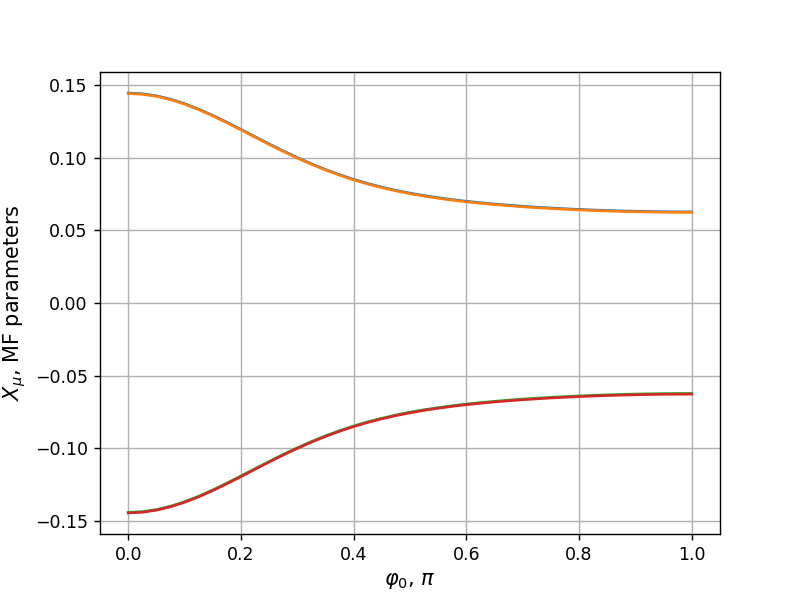

In [250]:
# plotting the resulting MF parameters

plt.plot(phi_0/np.pi, MF_param)
plt.xlabel(r'$\varphi_0$, $\pi$', fontsize=12)
plt.ylabel(r'$X_{\mu}$, MF parameters',  fontsize=12)
plt.grid()

<IPython.core.display.Javascript object>


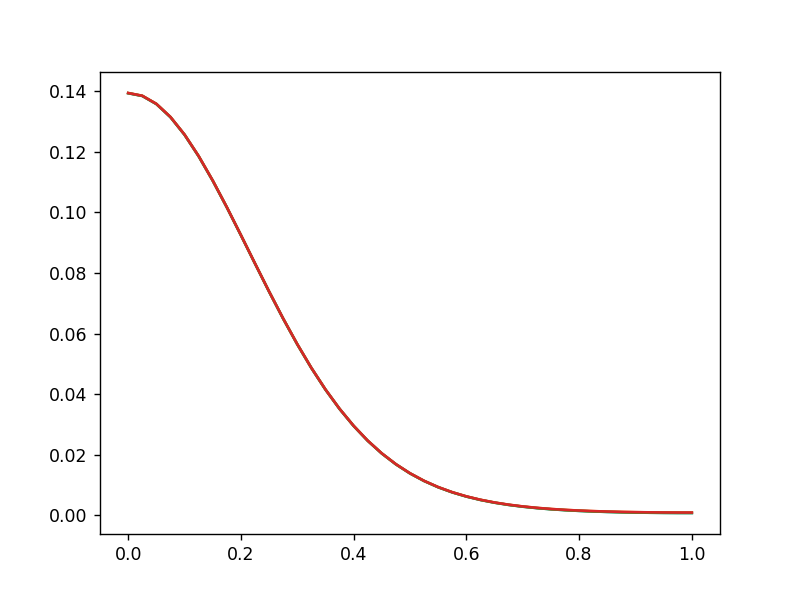

In [251]:
plt.plot(phi_0/np.pi, abs_diff)


### Calculating Josephson current and SCD efficiency for the obtained MF parameters

In [26]:
def deriv_Lambd(x, i):
    
    s_L = 1
    s_R = -1
    zero_m = np.zeros_like(Gamma_L)
    
    deriv_L = Delta / cmath.sqrt(Delta**2 - x**2) / (2*1j) * \
            (s_L * np.block([[zero_m, -np.exp(-1j * s_L * phi_0[i]/2) * np.conjugate(np.transpose(F_L))],\
                             [np.exp(1j * s_L * phi_0[i]/2) * F_L, zero_m]]) + \
             s_R * np.block([[zero_m, -np.exp(-1j * s_R * phi_0[i]/2) * np.conjugate(np.transpose(F_R))],\
                             [np.exp(1j * s_R * phi_0[i]/2) * F_R, zero_m]]))
    
    return deriv_L

In [27]:
def MS_current(i, MF_param):
    
    I = 0
    for j in range(len(ferm_freq)):
        I += np.trace(LA.inv(G_inv(ferm_freq[j], i, MF_param)) @ deriv_Lambd(ferm_freq[j], i))
        
    return I

In [28]:
# a helper function that computes the mean-field value at index i

def compute_single_curr(i):
    return MS_current(i, MF_param)

In [252]:
I_phi = np.array(
    Parallel(n_jobs=n_jobs)(
        delayed(compute_single_curr)(i) for i in range(len(phi_0))))

I_phi *= T_ferm

<IPython.core.display.Javascript object>


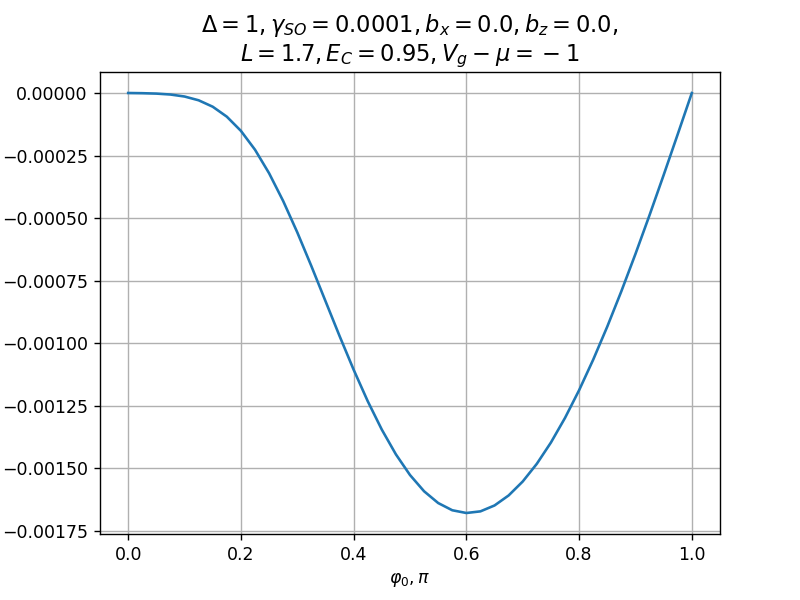

Text(0.5, 1.0, '$\\Delta=1,\\gamma_{SO} = 0.0001, b_x=0.0, b_z = 0.0,$\n$ L=1.7, E_C = 0.95, V_g-\\mu = -1$')

In [253]:
plt.plot(phi_0/np.pi, I_phi)
plt.grid()
plt.xlabel(r"$\varphi_0, \pi$")
plt.ylabel("I")
plt.title(r"$\Delta={},\gamma_{{SO}} = {}, b_x={}, b_z = {},$"\
          .format(Delta, gamma_SO, np.round(b_x, 2), np.round(b_z, 2))+'\n'+
          r"$ L={}, E_C = {}, V_g-\mu = {}$"\
          .format(L, Ec, Vg_min_mu), fontsize=13)

In [123]:
I_pl = np.max(I_phi)
I_min = np.max(-I_phi)

eta = np.abs(I_pl - I_min)/(I_pl + I_min)
print('eta = ', np.real(eta)*100, "%")

eta =  2.422125634563968 %
